Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Using device: cuda
Loading data from /content/drive/MyDrive/CryptoProject/processed_data_lstm/XRPUSDT...
Starting training for XRPUSDT...
Epoch 1/25, Train Loss: 0.965213, Val Loss: 0.974431 | LR: 0.000500
Epoch 2/25, Train Loss: 0.965478, Val Loss: 0.984666 | LR: 0.000500
EarlyStopping counter: 1 out of 25
Epoch 3/25, Train Loss: 0.964973, Val Loss: 0.955395 | LR: 0.000500
Epoch 4/25, Train Loss: 0.965359, Val Loss: 0.982997 | LR: 0.000500
EarlyStopping counter: 1 out of 25
Epoch 5/25, Train Loss: 0.960933, Val Loss: 0.963010 | LR: 0.000500
EarlyStopping counter: 2 out of 25
Epoch 6/25, Train Loss: 0.966963, Val Loss: 1.022498 | LR: 0.000500
EarlyStopping counter: 3 out of 25
Epoch 7/25, Train Loss: 0.963517, Val Loss: 1.006079 | LR: 0.000500
EarlyStopping counter: 4 out of 25
Epoch 8/25, Train Loss: 0.962448, Val Loss: 0.9

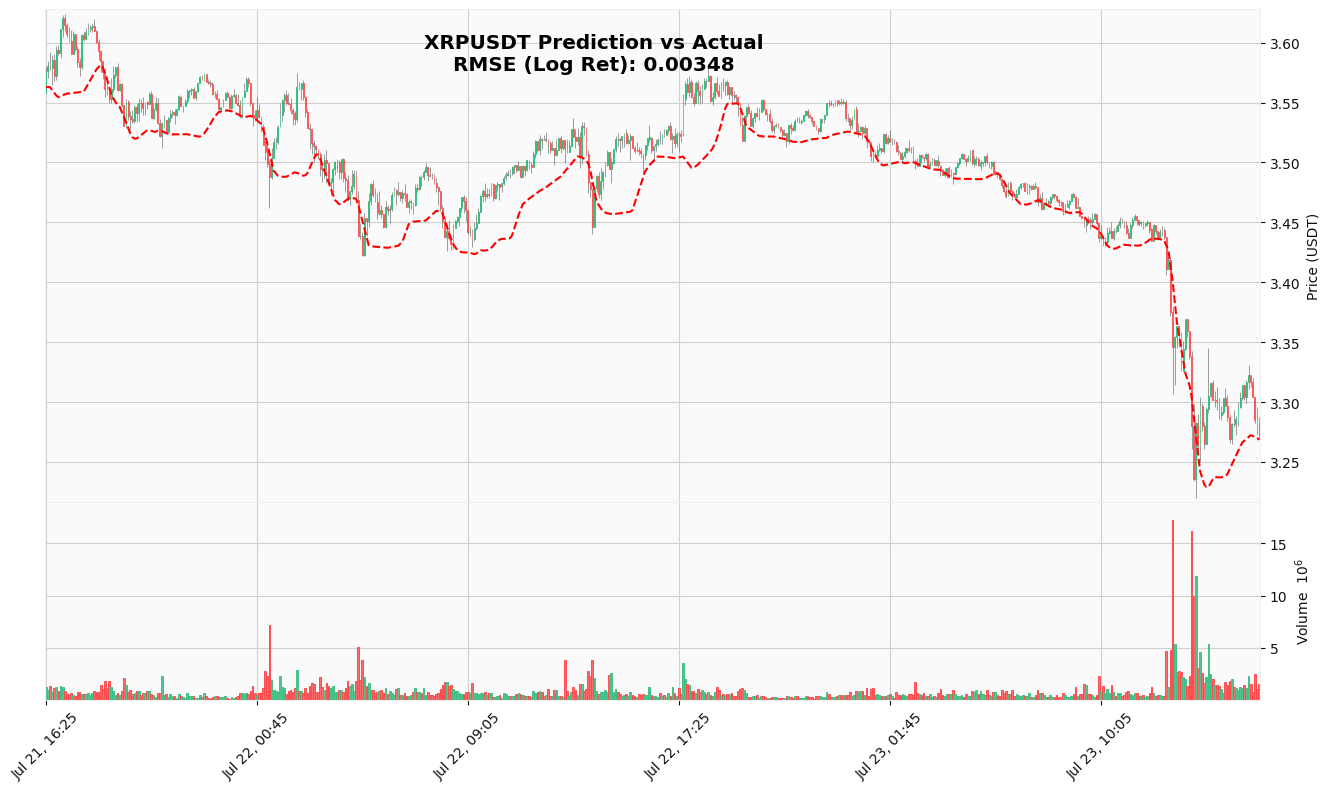

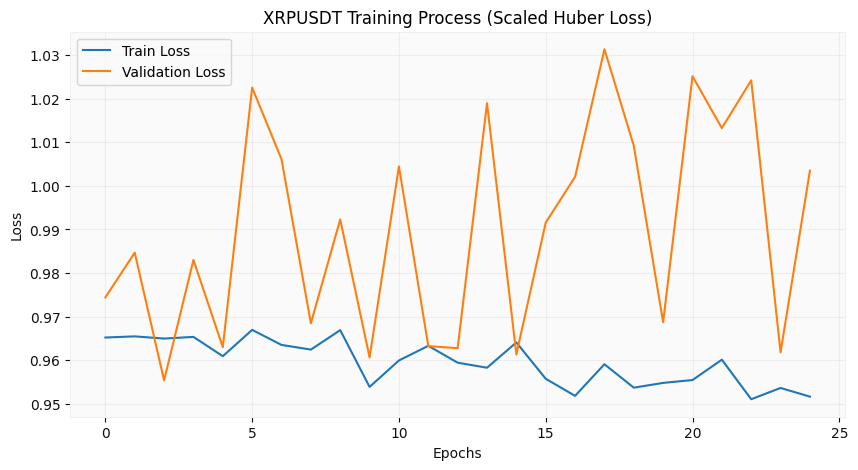

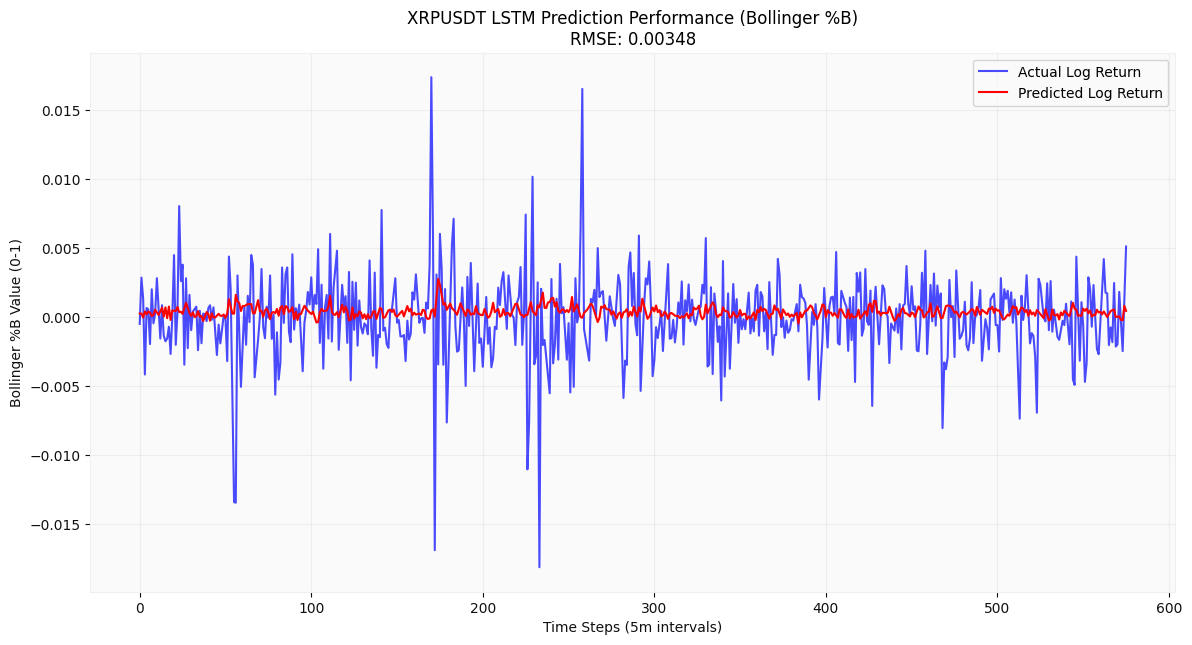


--- Accuracy on Strong Moves (Threshold 0.001): 60.75% (1261/8405 candles) ---

Exporting XRPUSDT LSTM results to Google Drive...
✅ XRPUSDT LSTM data saved successfully to /content/drive/MyDrive/CryptoProject/lstm_dashboard_data_XRPUSDT.csv!


In [2]:
%pip install torch ta mplfinance scikit-learn matplotlib pandas

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mplfinance as mpf
import pandas as pd
from sklearn.preprocessing import StandardScaler
import ta

# --- הגדרת המטבע ---
SYMBOL = 'XRPUSDT'
MODEL_TYPE = 'lstm'

# --- 1. חיבור לגוגל דרייב (מותאם לקולאב ולסביבה מקומית) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
    BASE_DIR = '/content/drive/MyDrive/CryptoProject'
except ImportError:
    print("Not running in Google Colab. Using local directory.")
    BASE_DIR = os.path.abspath(os.getcwd())

# --- הגדרות נתיבים דינמיים לפי המטבע ---
DATA_DIR = os.path.join(BASE_DIR, f'processed_data_{MODEL_TYPE}', SYMBOL)
MODEL_DIR = os.path.join(BASE_DIR, 'models')
CSV_PATH = os.path.join(BASE_DIR, 'data', f'{SYMBOL}_5m_data.csv')
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, f'best_{MODEL_TYPE}_model_{SYMBOL}.pth')
DASHBOARD_FILE_PATH = os.path.join(BASE_DIR, f'{MODEL_TYPE}_dashboard_data_{SYMBOL}.csv')

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"Created models directory at: {MODEL_DIR}")

# --- Fine Tuning Hyperparameters ---
BATCH_SIZE = 16
EPOCHS = 25
LEARNING_RATE = 0.0005
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.1

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_loss = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        self.best_loss = val_loss

def load_data():
    print(f"Loading data from {DATA_DIR}...")
    X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
    y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
    X_val = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
    y_val = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
    X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
    y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
    return X_train, y_train, X_val, y_val, X_test, y_test

def build_demo_loaders(fraction=0.05):
    X_train, y_train, X_val, y_val, X_test, y_test = load_data()
    train_size = int(len(X_train) * fraction)
    val_size = int(len(X_val) * fraction)
    test_size = int(len(X_test) * fraction)

    X_train = X_train[-train_size:]
    y_train = y_train[-train_size:]
    X_val = X_val[-val_size:]
    y_val = y_val[-val_size:]
    X_test = X_test[-test_size:]
    y_test = y_test[-test_size:]
    return X_train, y_train, X_val, y_val, X_test, y_test

class DirectionalLogCoshLoss(nn.Module):
    def __init__(self, directional_penalty=0.5):
        super(DirectionalLogCoshLoss, self).__init__()
        self.directional_penalty = directional_penalty

    def forward(self, y_pred, y_true):
        loss = torch.log(torch.cosh(y_pred - y_true + 1e-12))
        penalty = torch.where(y_pred * y_true < 0, self.directional_penalty, 0.0)
        return torch.mean(loss + penalty)

def calculate_directional_accuracy(y_true, y_pred, threshold=0.001):
    true_change = np.diff(y_true) / y_true[:-1]
    pred_change = np.diff(y_pred) / y_pred[:-1]
    significant_moves_mask = np.abs(pred_change) > threshold

    if np.sum(significant_moves_mask) == 0:
        print("No significant moves predicted.")
        return 0.0

    true_direction = np.sign(true_change[significant_moves_mask])
    pred_direction = np.sign(pred_change[significant_moves_mask])
    correct = np.sum(true_direction == pred_direction)
    total = len(true_direction)

    accuracy = (correct / total) * 100
    print(f"\n--- Accuracy on Strong Moves (Threshold {threshold}): {accuracy:.2f}% ({total}/{len(y_pred)} candles) ---")
    return accuracy

def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # X_train, y_train, X_val, y_val, X_test, y_test = load_data()
    X_train, y_train, X_val, y_val, X_test, y_test = build_demo_loaders(0.5)

    scaler = StandardScaler()
    N_samples, Seq_len, N_features = X_train.shape
    X_train_reshaped = X_train.reshape(-1, N_features)
    X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(N_samples, Seq_len, N_features)
    X_val_scaled = scaler.transform(X_val.reshape(-1, N_features)).reshape(X_val.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, N_features)).reshape(X_test.shape)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMModel(input_size=N_features, hidden_size=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
    criterion = DirectionalLogCoshLoss(directional_penalty=2)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, threshold=1e-5, min_lr=0.0001
    )
    early_stopping = EarlyStopping(patience=25, verbose=True, delta=1e-6)

    print(f"Starting training for {SYMBOL}...")
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs.squeeze(), y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

    print("\nEvaluating on Test Set...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    predictions = []
    with torch.no_grad():
        for X_batch, in test_loader:
            outputs = model(X_batch)
            predictions.extend(outputs.squeeze().cpu().numpy())

    predictions = np.array(predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"Final Test RMSE (Original Scale): {rmse:.6f}")

    print("\nGenerating Candle Visualization...")
    df_full = pd.read_csv(CSV_PATH)
    df_full['open_time'] = pd.to_datetime(df_full['open_time'])
    df_full.set_index('open_time', inplace=True)

    SEQ_LENGTH = 120
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1

    n = len(df_full)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))
    test_start_index = val_end + SEQ_LENGTH

    df_test_candles = df_full.iloc[test_start_index : test_start_index + len(predictions)].copy()

    bb = ta.volatility.BollingerBands(df_full['close'], window=20, window_dev=2)
    upper_band = bb.bollinger_hband().iloc[test_start_index : test_start_index + len(predictions)].values
    lower_band = bb.bollinger_lband().iloc[test_start_index : test_start_index + len(predictions)].values

    predicted_bb_price = lower_band + (np.array(predictions) * (upper_band - lower_band))
    df_test_candles['Predicted_Close'] = pd.Series(predicted_bb_price).rolling(window=3).mean().bfill().values

    ZOOM_SAMPLES = 576
    df_plot = df_test_candles.head(ZOOM_SAMPLES)

    apdict = mpf.make_addplot(df_plot['Predicted_Close'], type='line', color='red', linestyle='--', width=1.5, panel=0)
    title_text = f'{SYMBOL} Prediction vs Actual\nRMSE (Log Ret): {rmse:.5f}'

    mpf.plot(
        df_plot, type='candle', style='yahoo', addplot=apdict, volume=True,
        title=title_text, ylabel='Price (USDT)', figsize=(14, 8), tight_layout=True
    )

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{SYMBOL} Training Process (Scaled Huber Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(14, 7))
    plt.plot(y_test[:576], label='Actual Log Return', color='blue', alpha=0.7)
    plt.plot(predictions[:576], label='Predicted Log Return', color='red', linewidth=1.5)
    plt.title(f'{SYMBOL} LSTM Prediction Performance (Bollinger %B)\nRMSE: {rmse:.5f}')
    plt.xlabel('Time Steps (5m intervals)')
    plt.ylabel('Bollinger %B Value (0-1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    actual_prices = df_test_candles['close'].values
    calculate_directional_accuracy(actual_prices, predicted_bb_price)

    print(f"\nExporting {SYMBOL} LSTM results to Google Drive...")
    df_dashboard = df_test_candles[['open', 'high', 'low', 'close', 'volume']].copy()
    df_dashboard['Predicted_Close'] = df_test_candles['Predicted_Close']
    df_dashboard.to_csv(DASHBOARD_FILE_PATH)
    print(f"✅ {SYMBOL} LSTM data saved successfully to {DASHBOARD_FILE_PATH}!")

if __name__ == "__main__":
    train()